## **Retrieval-Augmented Generation (RAG) Pipeline**

## 🔍 **What is Retrieval-Augmented Generation (RAG)?**

Large Language Models (LLMs) are powerful but they have two problems:
1. They **forget facts** (limited by training data cutoff).
2. They sometimes **hallucinate answers**.

RAG solves this by combining two steps:
- **Retriever (ChromaDB)**: Finds the most relevant chunks of your documents (knowledge base).
- **Generator (LLM, e.g. Gemini)**: Reads both the user's question + retrieved chunks, then produces an answer.

👉 This lets you ask **knowledge-base-grounded questions** instead of relying on the LLM's broad training.

  **Basic RAG Pipeline**

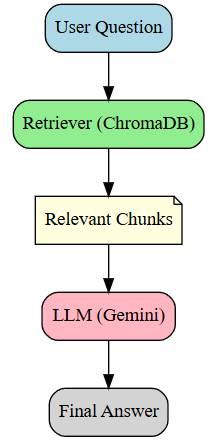

Today we will build a basic RAG pipeline in 3 steps:

1. Load and split documents

2. Store them in a vector database (Chroma)

3. Ask questions with retrieval + LLM

### **1. Install Dependencies**

Ensures all required Python packages (LangChain, ChromaDB, embeddings, LLM integration) are available. Fixes Colab-specific version conflicts.

In [1]:
# --- Clean reinstall Python packages ---
!pip uninstall -y langchain langchain-community
!pip install --quiet requests google-generativeai google-ai-generativelanguage
!pip install langchain langchain-community langchain-huggingface langchain-chroma langchain-google-genai
!pip install sentence-transformers pypdf gradio

Found existing installation: langchain 1.2.4
Uninstalling langchain-1.2.4:
  Successfully uninstalled langchain-1.2.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.4/719.4 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.9/234.9 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.0/329.0 kB 13.0 MB/s eta 0:00:00


### **2. Load Document**
Reads your PDF or other files into a standard format (Document objects) so they can be processed and embedded.

In [2]:
!pip install unstructured
!pip install "unstructured[pdf]"
from langchain_community.document_loaders import UnstructuredFileLoader
from langchain_community.document_loaders import DirectoryLoader

# Define the directory path
# This assumes the directory already exists with your files
data_dir = "/content/sample_data/data/"

# Use DirectoryLoader with UnstructuredFileLoader
# The glob="**/*" pattern tells it to look for all files in the directory and its subdirectories.
loader = DirectoryLoader(
    data_dir,
    glob="**/*",
    loader_cls=UnstructuredFileLoader,
    silent_errors=True
)
documents = loader.load()

# Print the number of documents loaded
print(f"Number of documents loaded: {len(documents)}")

# Print the source of each loaded document
print("\nSources of loaded documents:")
for doc in documents:
    print(doc.metadata.get('source'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 30.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.8/167.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 3.5 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=1d7d0061ab5e83fcec4e2c8f7e797bc75dadf2336f4e9e00685d65873035d81b
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

Number of documents loaded: 3

Sources of loaded documents:
/content/sample_data/data/10-Q4-2024-As-Filed.pdf
/content/sample_data/data/_10-K-2022-(As-Filed).pdf
/content/sample_data/data/_10-K-Q4-2023-As-Filed.pdf


### **3. Split into Chunks**

Breaks large documents into smaller, manageable pieces. Chunking preserves context and helps retrieval accuracy.

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
docs = splitter.split_documents(documents)

print(f"✅ Split into {len(docs)} chunks")
print("\n📄 Preview of first chunk:\n")
print(docs[0].page_content[:500], "...")

✅ Split into 2902 chunks

📄 Preview of first chunk:

UNITED STATES SECURITIES AND EXCHANGE COMMISSION Washington, D.C. 20549

FORM 10-K

(Mark One)

☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934 For the fiscal year ended September 28, 2024 or ☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934 For the transition period from to .

Commission File Number: 001-36743

Apple Inc.

(Exact name of Registrant as specified in its charter)

California

94-2404110 ...


### **4. Embed + Store in Chroma**
Converts each text chunk into a vector representation. ChromaDB stores vectors for fast similarity search.

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# Select an embedding model. Here, we will use HuggingFace embedding model (https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Initialize the vector store and populate it with vectorized data (e.g., embeddings from text chunks)
vector_store = Chroma.from_documents(
    documents=docs,
    collection_name="demo_collection",
    embedding=embeddings,
    persist_directory="./chroma_db"   # Save it to disk or a database so it can be reloaded later
)

print("✅ Vector store created successfully!")
print(f"Stored {vector_store._collection.count()} chunks in Chroma")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Vector store created successfully!
Stored 2902 chunks in Chroma


### **5. Connect Retriever + LLM**

Sets up the RAG pipeline: retriever finds relevant chunks, LLM reads them and the user query to generate an answer.

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from google.colab import userdata
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from operator import itemgetter

# RAG requires a generative model to produce the final answer. Here, we will use Gemini-2.5-Flash
api_key = userdata.get("GEMINI_API_KEY")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=api_key)

retriever = vector_store.as_retriever(search_kwargs={"k": 10})

template = """Answer the question based only on the following context:
{context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)

qa = (
    {"context": itemgetter("query") | retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print("✅ RAG pipeline ready!")

### **6. Try Queries**

Students can try questions and see how RAG pulls knowledge from the documents. Also allows comparison with LLM-only answers.

In [ ]:
query = "What is this document about?"

# Answer with RAG
response = qa.invoke({"query": query})
print("\n🤔 Question:", query)
print("💡 RAG Answer:", response)

# Compare with LLM alone
raw = llm.invoke(query)
print("\n🤔 Question:", query)
print("🗣️ LLM-only Answer:", raw.content)


🤔 Question: What is this document about?
💡 RAG Answer: This document is about provisions related to financial "Notes," including adding to or surrendering covenants for the benefit of noteholders, the succession and assumption of obligations under an Indenture (specifically concerning "Covenants—Consolidation, Merger and Sale of Assets"), and the definition of "U.S. government obligations" with respect to the 3.050% 2029 Notes and the 2042 Notes.

🤔 Question: What is this document about?
🗣️ LLM-only Answer: I cannot tell you what "this" document is about because you haven't provided the document to me.

Please provide the document's content (paste the text here), or describe it to me, and I'll do my best to summarize it for you!


In [ ]:
query = "What are the 3 key leadership characteristics expected by Steve Jobs?"

# Answer with RAG
response = qa.invoke({"query": query})
print("\n🤔 Question:", query)
print("💡 RAG Answer:", response)

# Compare with LLM alone
raw = llm.invoke(query)
print("\n🤔 Question:", query)
print("🗣️ LLM-only Answer:", raw.content)


🤔 Question: What are the 3 key leadership characteristics expected by Steve Jobs?
💡 RAG Answer: I'm sorry, but the provided context does not contain any information about Steve Jobs or the leadership characteristics he expected.

🤔 Question: What are the 3 key leadership characteristics expected by Steve Jobs?
🗣️ LLM-only Answer: Based on his career, public statements, and the accounts of those who worked with him, Steve Jobs expected and embodied these three key leadership characteristics:

1.  **Unwavering Vision and Innovation:** Jobs was a master at seeing the future, often before others could, and articulating a compelling vision for it. He expected leaders to not just manage existing products but to envision and create entirely new categories or radically redefine existing ones. This included challenging the status quo, thinking differently, and having the courage to pursue revolutionary ideas, even if they seemed impossible or unconventional.

2.  **Relentless Pursuit of Excell

In [ ]:
query = "Who is Paul Hubel?"

# Answer with RAG
response = qa.invoke({"query": query})
print("\n🤔 Question:", query)
print("💡 RAG Answer:", response)

# Compare with LLM alone
raw = llm.invoke(query)
print("\n🤔 Question:", query)
print("🗣️ LLM-only Answer:", raw.content)


🤔 Question: Who is Paul Hubel?
💡 RAG Answer: I cannot answer the question as the provided context does not contain any information about Paul Hubel. The documents mention Timothy D. Cook and Luca Maestri.

🤔 Question: Who is Paul Hubel?
🗣️ LLM-only Answer: Paul Hubel is a prominent **German political scientist and foreign policy expert.**

He is known for his work as a **Senior Fellow at the German Council on Foreign Relations (DGAP)**, a leading German think tank for foreign policy.

Key aspects of his career and expertise include:

*   **Political Advisor:** He has worked as a senior advisor in the German Bundestag (parliament) and at the Federal Foreign Office (Ministry of Foreign Affairs).
*   **Academic Background:** He has taught at the Humboldt University of Berlin.
*   **Areas of Expertise:** His research and commentary focus on German foreign policy, transatlantic relations (particularly with the USA), European security and defense policy, and relations with Russia and Easter

### **7. Deploy in Gradio**

### **Exercises**

Encourages students to tweak chunk size, overlap, top-k retrieval, and embeddings to see how performance changes.

* **Change chunk_size and chunk_overlap** → try 1000 with overlap 200.

* **Change** k → try k=1 vs k=5.

* **Compare RAG vs. LLM-only answers.**

In [ ]:
import gradio as gr

def compare_answers(user_query):
    # Get RAG answer
    rag_response = qa.invoke({"query": user_query})
    rag_answer = rag_response

    # Get LLM-only answer
    llm_response = llm.invoke(user_query)
    llm_answer = llm_response.content

    return rag_answer, llm_answer

with gr.Blocks() as demo:
    gr.Markdown("## 🔍 RAG vs LLM-only Answer Comparison")

    query_input = gr.Textbox(label="Enter your question", placeholder="Type any question here...", lines=1)
    submit_btn = gr.Button("Ask")

    rag_output = gr.Textbox(label="💡 RAG Answer", lines=5)
    llm_output = gr.Textbox(label="🗣️ LLM-only Answer", lines=5)

    submit_btn.click(fn=compare_answers, inputs=query_input, outputs=[rag_output, llm_output])
    query_input.submit(fn=compare_answers, inputs=query_input, outputs=[rag_output, llm_output])

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4ae4c98210c02b96dc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### **8. Appendix**

* **Load multiple files with DirectoryLoader**
  ```
  from langchain.document_loaders import UnstructuredFileLoader

  # Define the directory path
  # This assumes the directory already exists with your files
  data_dir = "/content/sample_data/data/"

  # Use DirectoryLoader with UnstructuredFileLoader
  # The glob="**/*" pattern tells it to look for all files in the directory and its subdirectories.
  loader = DirectoryLoader(
      data_dir,
      glob="**/*",
      loader_cls=UnstructuredFileLoader,
      silent_errors=True
  )
  documents = loader.load()

  # Print the number of documents loaded
  print(f"Number of documents loaded: {len(documents)}")

  # Print the source of each loaded document
  print("\nSources of loaded documents:")
  for doc in documents:
      print(doc.metadata.get('source'))
  ```

* **Add a re-ranker**
  ```
  from langchain.retrievers import ContextualCompressionRetriever
  from langchain.retrievers.document_compressors import CrossEncoderReranker
  from langchain_community.cross_encoders import HuggingFaceCrossEncoder

  # Initialize a cross-encoder model for re-ranking
  model_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"
  cross_encoder_model = HuggingFaceCrossEncoder(model_name=model_name, model_kwargs={'device': 'cpu'})

  # Initialize a retriever that retrieves more documents than needed (e.g., k=10)
  # This gives the re-ranker a larger pool of documents to work with
  retriever = vector_store.as_retriever(search_kwargs={"k": K})

  # Create the re-ranker
  reranker = CrossEncoderReranker(model=cross_encoder_model, top_n=3)

  # Create the ContextualCompressionRetriever with the re-ranker
  retriever = ContextualCompressionRetriever(
      base_compressor=reranker,
      base_retriever=retriever
  )
  ```

* **Try larger embedding models like `all-mpnet-base-v2`**